# 02 Baseline Ingenuo

**Proyecto:** Predicción de demanda E-commerce R4
**Iteración:** 0 (suelo de rendimiento)

## Objetivo

Establecer un baseline de referencia mediante una predicción ingenua que no usa Machine Learning; para cada combinación `(Store, DayOfWeek)`, predecir la **media histórica de ventas** observada en el conjunto de entrenamiento.

## Justificación

Antes de entrenar modelos sofisticados es imprescindible cuantificar lo bueno que sería un enfoque trivial. Este baseline:

1. **Acota el problema**: indica el error mínimo que cualquier modelo de ML debe superar para aportar valor.
2. **Facilita la comparación entre iteraciones**: todas las métricas posteriores se interpretarán como "% de mejora respecto al baseline".
3. **Cumple la metodología profesional**: alineado con la recomendación de establecer un punto de partida medible antes de iterar.

## Métrica principal

**RMSPE** (Root Mean Square Percentage Error) — métrica oficial de la competición Rossmann y la más adecuada para problemas de demanda con ventas heterogéneas entre tiendas. Se complementa con RMSE y MAE.

In [2]:
!pip install seaborn

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from io import BytesIO

# Configuración
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 100)

print("Imports cargados")

Imports cargados


In [4]:
# Carga de datos desde S3
BUCKET_NAME = "prediccion-demanda-processed-319501512128"
PREFIX_SPLITS = "rossmann/splits/"
TIMESTAMP = "20260410_054619"

s3_client = boto3.client("s3")

def load_csv_from_s3(bucket, key):
    response = s3_client.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(BytesIO(response["Body"].read()))

print("Cargando splits...")
df_train = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}train_{TIMESTAMP}.csv")
df_val = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}validation_{TIMESTAMP}.csv")
df_test = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}test_{TIMESTAMP}.csv")

# Convertimos Date a datetime
for df in [df_train, df_val, df_test]:
    df["Date"] = pd.to_datetime(df["Date"])

print(f"Train: {df_train.shape}")
print(f"Val:   {df_val.shape}")
print(f"Test:  {df_test.shape}")

Cargando splits...
Train: (591036, 20)
Val:   (126651, 20)
Test:  (126651, 20)


In [5]:
# Métricas de evaluación
def rmspe(y_true, y_pred):
    """
    Métrica oficial de la competición Rossmann.
    Ignora los valores y_true == 0 para evitar división por cero.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

def evaluate(y_true, y_pred, label=""):
    """Calcula y muestra las 3 métricas."""
    metrics = {
        "RMSPE": rmspe(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
    }
    if label:
        print(f"{label}")
    print(f"   RMSPE: {metrics['RMSPE']:.4f}  ({metrics['RMSPE']*100:.2f}%)")
    print(f"   RMSE:  {metrics['RMSE']:.2f} €")
    print(f"   MAE:   {metrics['MAE']:.2f} €")
    return metrics

print("Funciones de métricas definidas")

Funciones de métricas definidas


In [6]:
# Construcción del baseline
print("Calculando medias históricas por.....")

# Agrupamos en train para obtener la tabla de predicciones
baseline_table = (
    df_train.groupby(["Store", "DayOfWeek"])["Sales"]
    .mean()
    .reset_index()
    .rename(columns={"Sales": "PredictedSales"})
)

print(f"Tabla de baseline: {baseline_table.shape}")
print(f"Combinaciones únicas (Store × DayOfWeek): {baseline_table.shape[0]}")
print("\nPrimeras filas de la tabla del baseline:")
baseline_table.head(10)

Calculando medias históricas por.....
Tabla de baseline: (6723, 3)
Combinaciones únicas (Store × DayOfWeek): 6723

Primeras filas de la tabla del baseline:


,Store,DayOfWeek,PredictedSales
0,1,1,5160.460674
1,1,2,4655.161290
2,1,3,4588.219780
3,1,4,4420.689655
4,1,5,4753.043956
5,1,6,4880.425532
6,2,1,5979.573034
7,2,2,5186.311828
8,2,3,5815.659341
9,2,4,4896.123596


In [7]:
# Predicción sobre validation
df_val_pred = df_val.merge(baseline_table, on=["Store", "DayOfWeek"], how="left")

# Comprobación
missing = df_val_pred["PredictedSales"].isnull().sum()
if missing > 0:
    print(f"{missing} filas sin predicción (combinación no vista en train)")
    # Usamos la media global de train
    global_mean = df_train["Sales"].mean()
    df_val_pred["PredictedSales"] = df_val_pred["PredictedSales"].fillna(global_mean)
    print(f"   Imputadas con la media global: {global_mean:.2f} €")
else:
    print("Todas las combinaciones de validation tienen predicción")

# Evaluación
print("\n" + "=" * 60)
metrics_baseline_val = evaluate(
    df_val_pred["Sales"],
    df_val_pred["PredictedSales"],
    label="BASELINE INGENUO Validation"
)
print("=" * 60)

Todas las combinaciones de validation tienen predicción

BASELINE INGENUO Validation
   RMSPE: 0.3803  (38.03%)
   RMSE:  1850.47 €
   MAE:   1325.99 €


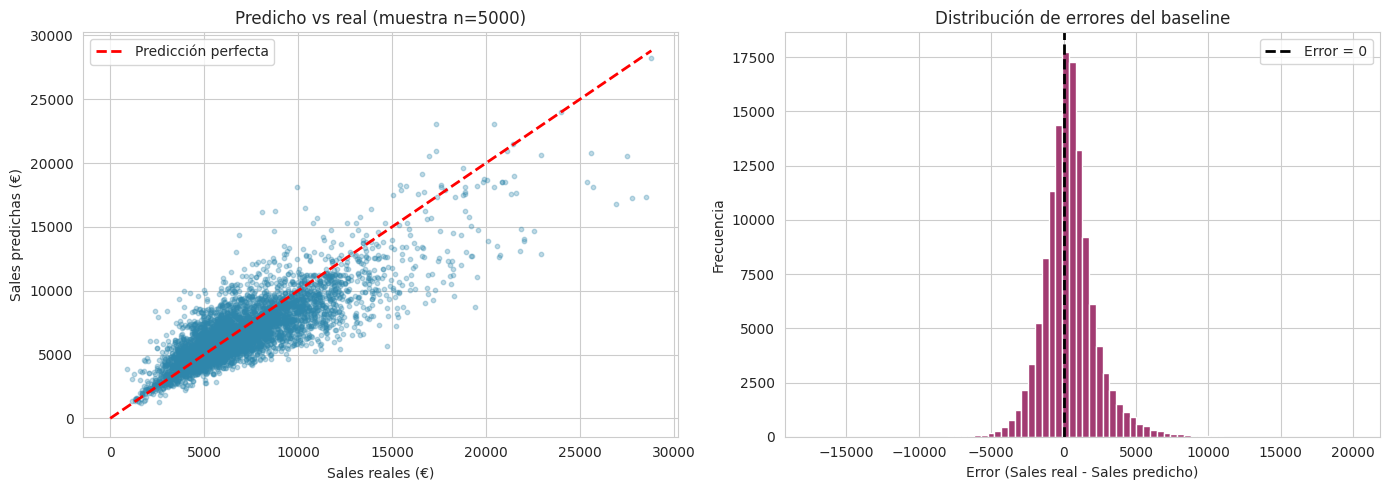

Error medio: 396.82 €
Desviación de errores: 1807.43 €


In [8]:
# Visualización, predicho vs real. Muestra de 5000 puntos
sample = df_val_pred.sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter predicho vs real
axes[0].scatter(sample["Sales"], sample["PredictedSales"], alpha=0.3, s=10, color="#2E86AB")
max_val = max(sample["Sales"].max(), sample["PredictedSales"].max())
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Predicción perfecta")
axes[0].set_xlabel("Sales reales (€)")
axes[0].set_ylabel("Sales predichas (€)")
axes[0].set_title("Predicho vs real (muestra n=5000)")
axes[0].legend()

# Distribución de errores
errors = df_val_pred["Sales"] - df_val_pred["PredictedSales"]
axes[1].hist(errors, bins=80, color="#A23B72", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", linewidth=2, label="Error = 0")
axes[1].set_xlabel("Error (Sales real - Sales predicho)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de errores del baseline")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/plots/baseline_predicted_vs_real.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Error medio: {errors.mean():.2f} €")
print(f"Desviación de errores: {errors.std():.2f} €")

In [9]:
# Guardar métricas para la tabla comparativa final
import os
os.makedirs("../results", exist_ok=True)

results_path = "../results/metrics_comparison.csv"

# Si el archivo no existe, lo creamos. Si existe, añadimos fila.
new_row = pd.DataFrame([{
    "Iteration": 0,
    "Model": "Baseline Ingenuo (media Store×DayOfWeek)",
    "Split": "Validation",
    "RMSPE": metrics_baseline_val["RMSPE"],
    "RMSE": metrics_baseline_val["RMSE"],
    "MAE": metrics_baseline_val["MAE"],
}])

if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    # Eliminamos cualquier fila previa de la iteración 0 para evitar duplicados al re-ejecutar
    existing = existing[existing["Iteration"] != 0]
    results_df = pd.concat([existing, new_row], ignore_index=True)
else:
    results_df = new_row

results_df.to_csv(results_path, index=False)
print(f"Métricas guardadas en {results_path}")
print("\nTabla de resultados acumulada:")
print(results_df.to_string(index=False))

Métricas guardadas en ../results/metrics_comparison.csv

Tabla de resultados acumulada:
 Iteration                                    Model      Split    RMSPE        RMSE         MAE
         0 Baseline Ingenuo (media Store×DayOfWeek) Validation 0.380258 1850.471558 1325.987539


## Resultados de la iteración 0

El baseline ingenuo establece un suelo de rendimiento contra el que compararemos las siguientes iteraciones. Los valores obtenidos en validation servirán como referencia para cuantificar el aporte real de cada modelo de machine learning.

**Próxima iteración:** Linear Learner entrenado con las features básicas del ETL para validar que un modelo lineal supera al baseline ingenuo.